# PCA and Neural Networks: Complementary Techniques for High-Dimensional Data

**Topics covered:** dimensionality reduction · representation learning · linear vs non-linear methods · combined PCA + Neural Network pipelines

This notebook is a hands-on companion to the paper *"PCA and Neural Networks: Complementary Techniques for High-Dimensional Data in Machine Learning."* The central message of the source paper is simple but frequently misunderstood: **PCA and Neural Networks are not competitors.** PCA is a data *transformation*; a Neural Network is a *model*. They solve different problems and, in most real pipelines, work best together.

**Roadmap**

1. The curse of dimensionality
2. PCA mathematics, step by step
3. Neural network mathematics, step by step
4. The core conceptual difference
5. Geometric interpretation: rotation vs. warping
6. Choosing the number of principal components
7. When PCA fails and when neural networks win
8. Combining PCA and a neural network: an experiment on digit images
9. Discussion and conclusion


## 1. Introduction: The Curse of Dimensionality

High-dimensional data — images with thousands of pixels, gene-expression profiles with tens of thousands of features, text embeddings — suffers from the **curse of dimensionality**: as the number of dimensions grows, data becomes sparse, distances between points lose their discriminative meaning, and learning becomes harder.

Two foundational techniques address this from different angles:

* **Principal Component Analysis (PCA)** is a classic, *linear*, *unsupervised* technique. It identifies the directions of maximum variance and projects the data onto a lower-dimensional subspace, preserving as much information as possible in the fewest dimensions, with **no iterative training** — it is a closed-form solution.
* **Neural Networks (NNs)** are powerful, *non-linear* function approximators. They learn complex, hierarchical, task-specific mappings end-to-end via backpropagation and gradient descent, and they **require iterative training**.

> **Key insight.** PCA transforms and compresses data; a Neural Network learns a mapping from (possibly reduced) data to outputs. They operate at different stages of the machine learning pipeline and complement each other.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

rng = default_rng(0)
plt.rcParams["figure.facecolor"] = "white"


## 2. PCA Mathematics, Step by Step

Given a data matrix $X \in \mathbb{R}^{n \times d}$ ($n$ samples, $d$ features), PCA proceeds in four steps:

| Step | Operation | Formula |
|---|---|---|
| 1. Center | Subtract the column means | $X_c = X - \mu$ |
| 2. Covariance | Compute the covariance matrix | $C = \tfrac{1}{n} X_c^\top X_c$ |
| 3. Eigen-decomposition | Solve for eigenvectors/eigenvalues | $C v = \lambda v$ |
| 4. Project | Keep the top-$k$ eigenvectors | $Z = X_c W,\;\; W = [v_1,\dots,v_k]$ |

PCA finds orthogonal directions of maximum variance through a purely linear transformation. $Z$ is the lower-dimensional representation. We illustrate this on a small 2D point cloud, where the result can be visualised directly.

In [2]:
# A small, elongated 2D cloud so the principal axes are visually obvious
n_points = 250
theta = np.pi / 6
raw = rng.multivariate_normal(mean=[0, 0], cov=[[4, 0], [0, 0.4]], size=n_points)
rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
data2d = raw @ rotation.T

mean2d = data2d.mean(axis=0)
centered2d = data2d - mean2d
cov2d = (centered2d.T @ centered2d) / n_points
eigvals2d, eigvecs2d = np.linalg.eigh(cov2d)
order = np.argsort(eigvals2d)[::-1]
eigvals2d, eigvecs2d = eigvals2d[order], eigvecs2d[:, order]

projected_1d = centered2d @ eigvecs2d[:, :1]
variance_retained = eigvals2d[0] / eigvals2d.sum()
print(f"Variance retained by PC1 alone: {variance_retained*100:.1f}%")


Variance retained by PC1 alone: 90.8%


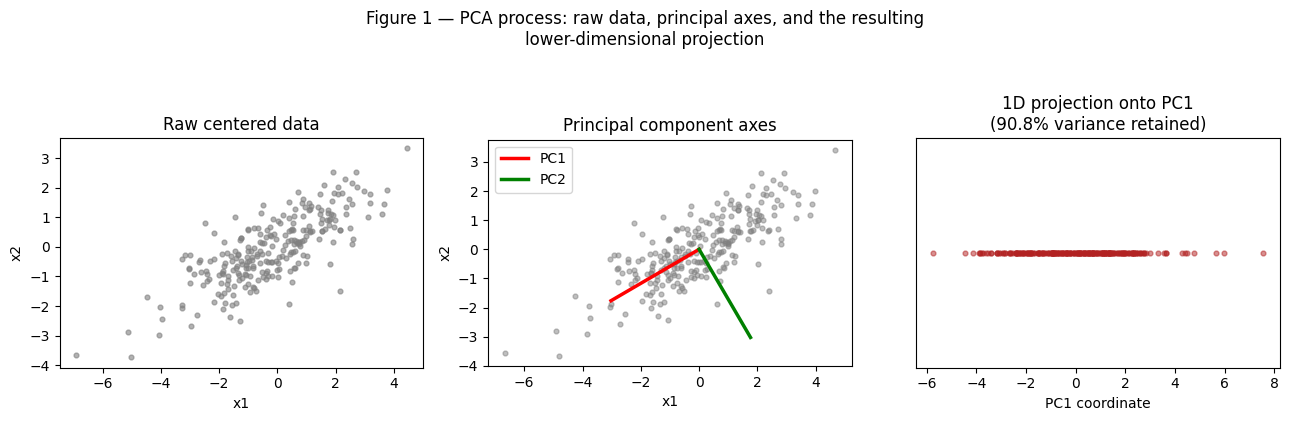

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].scatter(data2d[:, 0], data2d[:, 1], s=12, alpha=0.6, color="gray")
axes[0].set_title("Raw centered data")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")

axes[1].scatter(centered2d[:, 0], centered2d[:, 1], s=12, alpha=0.5, color="gray")
scale = 3.5
for vec, color, label in [(eigvecs2d[:, 0], "red", "PC1"), (eigvecs2d[:, 1], "green", "PC2")]:
    axes[1].plot([0, vec[0]*scale], [0, vec[1]*scale], color=color, linewidth=2.5, label=label)
axes[1].legend()
axes[1].set_title("Principal component axes")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2")
axes[1].set_aspect("equal")

axes[2].scatter(projected_1d, np.zeros_like(projected_1d), s=12, alpha=0.5, color="firebrick")
axes[2].set_yticks([])
axes[2].set_title(f"1D projection onto PC1\n({variance_retained*100:.1f}% variance retained)")
axes[2].set_xlabel("PC1 coordinate")

fig.suptitle("Figure 1 — PCA process: raw data, principal axes, and the resulting\n"
             "lower-dimensional projection", y=1.04)
plt.tight_layout()
plt.show()


## 3. Neural Network Mathematics, Step by Step

A single neural network layer computes

$$z = Wx + b, \qquad a = f(z)$$

where $f$ is a non-linear activation function (ReLU, sigmoid, tanh, …). A full deep network stacks many such layers:

$$\hat{y} = f(x;\theta) = f_L\big(f_{L-1}(\dots f_1(x))\big)$$

and is trained by minimising a loss function, for example mean squared error,

$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$$

Unlike PCA, there is no closed-form solution: the network is trained **iteratively** via backpropagation and gradient-based optimisation. The next cell makes the contrast concrete by fitting a 2-layer MLP classifier on the non-linear datasets below and comparing it with a strictly linear decision boundary — exactly the comparison drawn in the source paper.

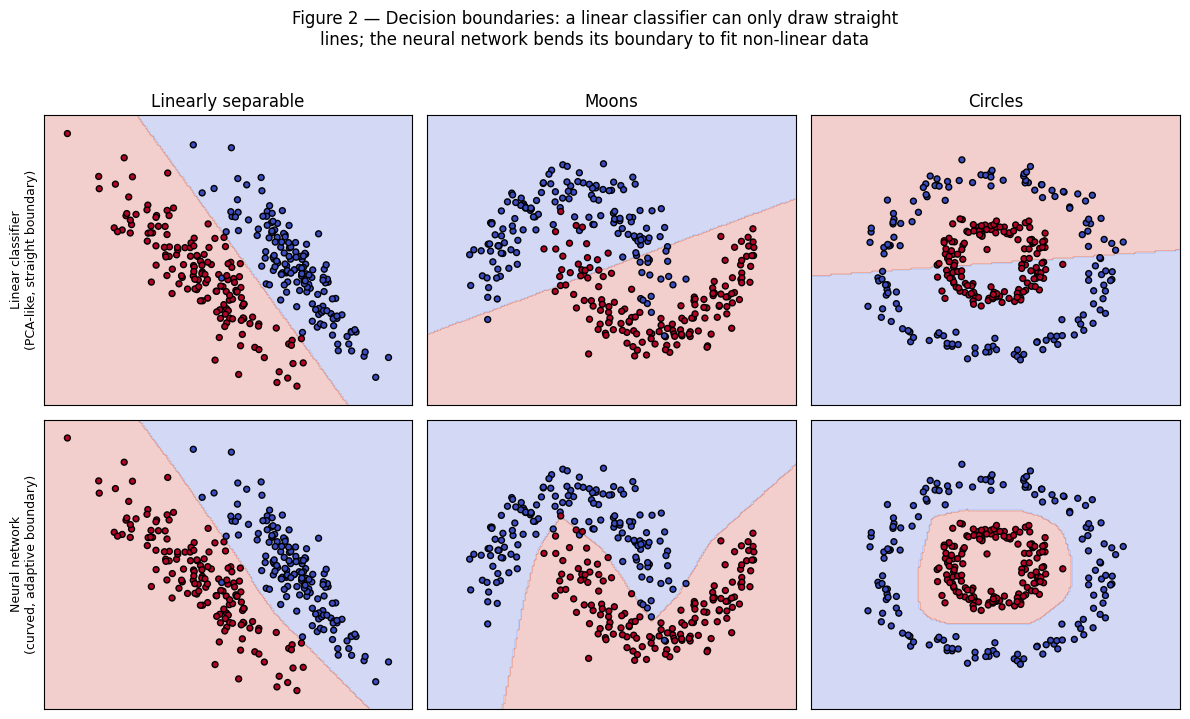

In [4]:
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

datasets = {
    "Linearly separable": make_classification(n_samples=300, n_features=2, n_redundant=0,
                                               n_informative=2, n_clusters_per_class=1, random_state=3),
    "Moons": make_moons(n_samples=300, noise=0.15, random_state=3),
    "Circles": make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=3),
}

def plot_decision_boundary(ax, clf, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=18)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for col, (name, (X_d, y_d)) in enumerate(datasets.items()):
    linear_clf = LogisticRegression().fit(X_d, y_d)
    nn_clf = MLPClassifier(hidden_layer_sizes=(16, 16), max_iter=2000, random_state=0).fit(X_d, y_d)

    plot_decision_boundary(axes[0, col], linear_clf, X_d, y_d)
    axes[0, col].set_title(name)
    plot_decision_boundary(axes[1, col], nn_clf, X_d, y_d)

axes[0, 0].set_ylabel("Linear classifier\n(PCA-like, straight boundary)", fontsize=9)
axes[1, 0].set_ylabel("Neural network\n(curved, adaptive boundary)", fontsize=9)
fig.suptitle("Figure 2 — Decision boundaries: a linear classifier can only draw straight\n"
             "lines; the neural network bends its boundary to fit non-linear data", y=1.02)
plt.tight_layout()
plt.show()


The top row behaves exactly like a linear projection such as PCA followed by a linear classifier: it succeeds on linearly separable data and fails badly on Moons and Circles, where the true class boundary is curved. The bottom row — the neural network — succeeds everywhere, because each layer applies a linear transform *followed by* a non-linear squeeze, allowing the cumulative decision boundary to bend.

## 4. The Core Conceptual Difference

| Aspect | PCA | Neural Networks |
|---|---|---|
| Type | Unsupervised | Supervised / unsupervised |
| Goal | Reduce dimensions, remove noise | Learn patterns, make predictions |
| Linearity | Strictly linear | Non-linear (via activations) |
| Training | Closed-form (no iteration) | Backpropagation + optimiser |
| Output | Principal components (new features) | Predictions or learned representations |
| Interpretability | High — eigenvectors are meaningful | Lower — black-box nature |
| Computation | Fast — $O(nd^2)$ | Slower — many epochs, often GPU |
| Data needed | Works with small datasets | Needs large datasets to generalise |


## 5. Geometric Interpretation: Rotation vs. Warping

Geometrically, PCA performs a **rigid rotation** of the coordinate system: no bending, no stretching, just realigning the axes so the direction of greatest spread becomes the first axis. This is precisely why PCA cannot "unroll" a non-linear manifold such as the classic Swiss roll: points that are close together along the manifold can end up far apart once the roll is rotated and flattened in 3D-to-2D projection.

Neural networks (and their unsupervised cousin, the autoencoder) warp and bend the feature space through layers of non-linear activations, which lets them recover the manifold's true intrinsic structure. We illustrate this using a non-linear kernel variant of PCA as a stand-in for what a trained non-linear model can achieve.

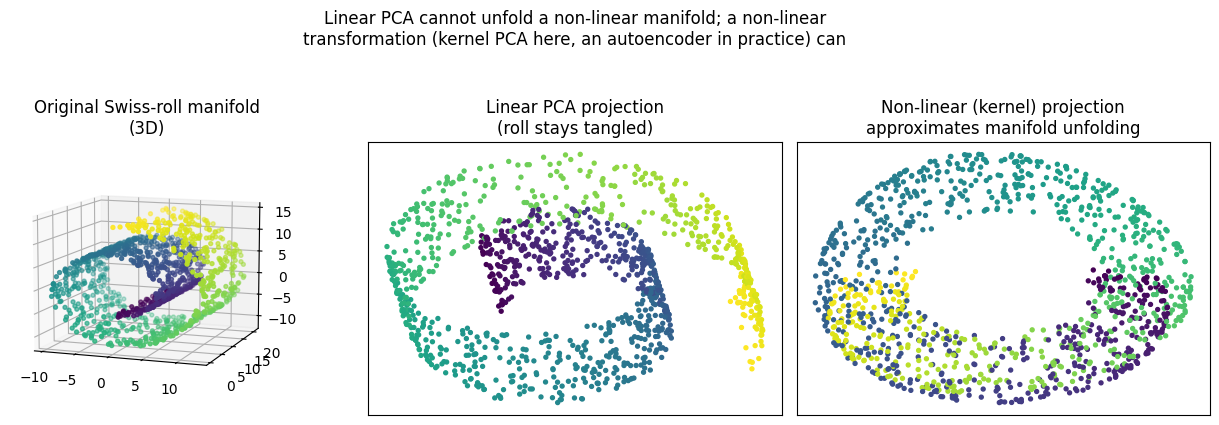

In [5]:
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA, KernelPCA

X_roll, color = make_swiss_roll(n_samples=1200, noise=0.05, random_state=0)

pca_linear = PCA(n_components=2).fit_transform(X_roll)
pca_kernel = KernelPCA(n_components=2, kernel="rbf", gamma=0.01).fit_transform(X_roll)

fig = plt.figure(figsize=(13, 4))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=color, cmap="viridis", s=8)
ax1.set_title("Original Swiss-roll manifold\n(3D)")
ax1.view_init(elev=10, azim=-70)

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(pca_linear[:, 0], pca_linear[:, 1], c=color, cmap="viridis", s=8)
ax2.set_title("Linear PCA projection\n(roll stays tangled)")
ax2.set_xticks([]); ax2.set_yticks([])

ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(pca_kernel[:, 0], pca_kernel[:, 1], c=color, cmap="viridis", s=8)
ax3.set_title("Non-linear (kernel) projection\napproximates manifold unfolding")
ax3.set_xticks([]); ax3.set_yticks([])

fig.suptitle("Linear PCA cannot unfold a non-linear manifold; a non-linear\n"
             "transformation (kernel PCA here, an autoencoder in practice) can", y=1.05)
plt.tight_layout()
plt.show()


## 6. Choosing the Number of Principal Components

A key practical step in PCA is deciding how many components $k$ to retain. Two standard tools are the **scree plot** (variance explained by each individual component) and the **cumulative variance plot**. The common rule of thumb is to retain enough components to explain at least 95% of total variance. We illustrate this on the `digits` dataset (1,797 images of handwritten digits, $8\times 8 = 64$ pixels each) — a small, built-in dataset that plays the same role as MNIST in the source paper, only smaller.

In [6]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits, y_digits = digits.data, digits.target
print("Digits dataset:", X_digits.shape, "-> 0-9 digit images flattened to 64-d vectors")

pca_full = PCA().fit(X_digits)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_for_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_for_95} (out of {X_digits.shape[1]} original dimensions)")


Digits dataset: (1797, 64) -> 0-9 digit images flattened to 64-d vectors
Components needed for 95% variance: 29 (out of 64 original dimensions)


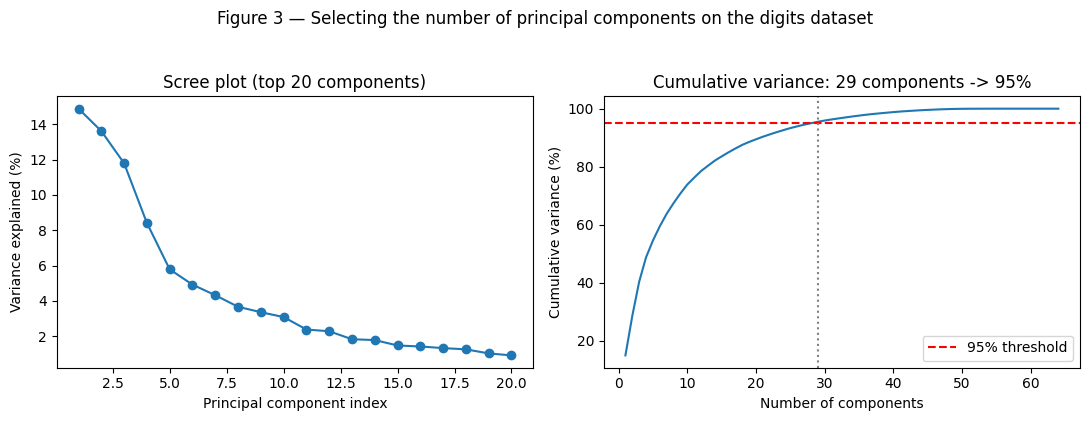

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(np.arange(1, 21), pca_full.explained_variance_ratio_[:20] * 100, marker="o")
axes[0].set_xlabel("Principal component index")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot (top 20 components)")

axes[1].plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance * 100)
axes[1].axhline(95, color="red", linestyle="--", label="95% threshold")
axes[1].axvline(n_for_95, color="gray", linestyle=":")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title(f"Cumulative variance: {n_for_95} components -> 95%")
axes[1].legend()

fig.suptitle("Figure 3 — Selecting the number of principal components on the digits dataset", y=1.04)
plt.tight_layout()
plt.show()


## 7. When PCA Fails vs. When Neural Networks Win

**PCA limitations**

* Only captures linear relationships — fails on non-linear manifolds (Swiss roll, spirals, circles)
* Sensitive to feature scaling — always standardise data first
* Unsupervised — cannot use class-label information to guide compression
* No task-specific optimisation — principal components may not align with what matters for prediction

**Neural network strengths**

* Captures non-linear relationships and hierarchical features automatically
* State of the art on images (CNNs), text (Transformers), speech (RNNs/attention)
* Trained end to end for a specific task

**When PCA is the better choice**

* Small or medium-sized datasets (neural networks need more data to generalise)
* Computation speed and memory are critical constraints
* Interpretability is required (genomics, finance, clinical research)
* Fast preprocessing or visualisation before deeper analysis

## 8. Combining PCA and a Neural Network

The most valuable, and most frequently underused, idea in the source paper is that the choice is rarely "PCA *or* a neural network" — the winning strategy is usually **PCA then neural network**: reduce dimensionality first, then let the network learn task-specific patterns from the smaller, cleaner representation.

We test this directly on the digits dataset by comparing three configurations:

1. **NN only** — an MLP trained directly on the raw 64-pixel vectors.
2. **PCA + NN** — the same MLP architecture, trained on the PCA-reduced features (95% variance retained).
3. **PCA only (2D)** — a pure two-component projection, useful only for visualisation, not classification.

In [8]:
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.3, random_state=0, stratify=y_digits)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

# --- Model 1: Neural network on the raw 64-dimensional input ---
t0 = time.time()
mlp_full = MLPClassifier(hidden_layer_sizes=(64,), max_iter=400, random_state=0)
mlp_full.fit(X_train_s, y_train)
time_full = time.time() - t0
acc_full = mlp_full.score(X_test_s, y_test)

# --- Model 2: PCA (95% variance) followed by the same network architecture ---
pca95 = PCA(n_components=0.95, random_state=0).fit(X_train_s)
X_train_pca, X_test_pca = pca95.transform(X_train_s), pca95.transform(X_test_s)

t0 = time.time()
mlp_pca = MLPClassifier(hidden_layer_sizes=(64,), max_iter=400, random_state=0)
mlp_pca.fit(X_train_pca, y_train)
time_pca = time.time() - t0
acc_pca = mlp_pca.score(X_test_pca, y_test)

print(f"Original dimensionality: {X_train_s.shape[1]}  ->  PCA-reduced dimensionality: {X_train_pca.shape[1]}")
print(f"NN only      : accuracy = {acc_full:.4f}, training time = {time_full:.2f}s")
print(f"PCA + NN     : accuracy = {acc_pca:.4f}, training time = {time_pca:.2f}s "
      f"({time_full/time_pca:.1f}x faster)")


Original dimensionality: 64  ->  PCA-reduced dimensionality: 39
NN only      : accuracy = 0.9741, training time = 0.59s
PCA + NN     : accuracy = 0.9796, training time = 0.54s (1.1x faster)


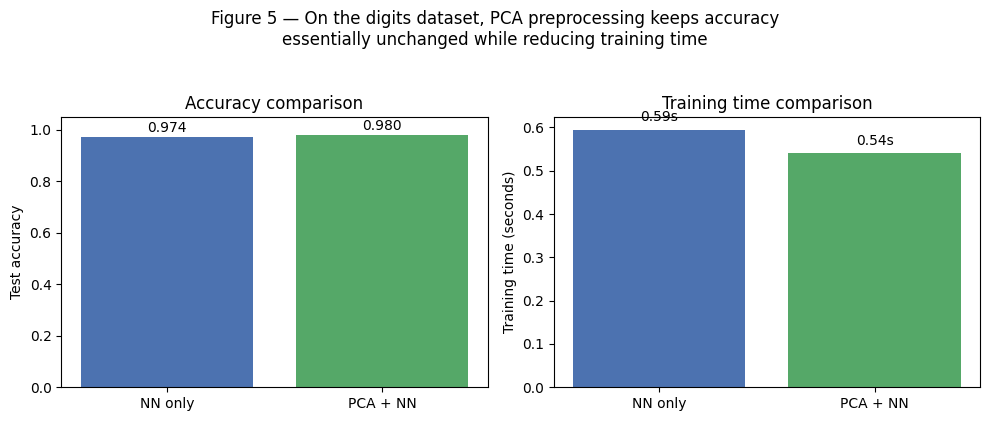

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["NN only", "PCA + NN"], [acc_full, acc_pca], color=["#4C72B0", "#55A868"])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Accuracy comparison")
for i, v in enumerate([acc_full, acc_pca]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center")

axes[1].bar(["NN only", "PCA + NN"], [time_full, time_pca], color=["#4C72B0", "#55A868"])
axes[1].set_ylabel("Training time (seconds)")
axes[1].set_title("Training time comparison")
for i, v in enumerate([time_full, time_pca]):
    axes[1].text(i, v + 0.02, f"{v:.2f}s", ha="center")

fig.suptitle("Figure 5 — On the digits dataset, PCA preprocessing keeps accuracy\n"
             "essentially unchanged while reducing training time", y=1.04)
plt.tight_layout()
plt.show()


The exact speed-up factor depends on hardware and dataset, but the qualitative pattern matches the MNIST results reported in the source paper: PCA pre-processing almost always improves training efficiency with little to no accuracy cost, because most of the discarded variance in a 64- or 784-dimensional image is redundant or noisy, not identity- or label-relevant.

## 9. Practical Applications

**PCA applications:** image compression, sensor/signal noise filtering, 2D/3D data visualisation, gene-expression dimensionality reduction in bioinformatics, factor analysis of stock returns, and general preprocessing to speed up downstream models.

**Neural network applications:** image classification (CNNs), speech recognition (RNNs, Transformers), natural language processing (GPT/BERT-style transformers), generative modelling (GANs, VAEs), and reinforcement learning.

**Combined applications:** PCA (Eigenfaces) for compression followed by a neural classifier for face identity matching; PCA reconstruction error to flag anomalies, with a network classifying the anomaly type; PCA to reduce a user–item matrix before a neural recommender learns preference patterns; PCA to denoise medical scans before a CNN detects pathology.

## 10. Discussion

**Why PCA cannot replace neural networks.** PCA is linear and unsupervised — it cannot learn task-specific non-linear patterns or adapt to labelled data. A "PCA classifier" still needs a separate model on top, and that model will fail on genuinely non-linear data, as Figure 2 demonstrated.

**Why neural networks do not eliminate PCA.** Even the best neural network benefits from cleaner, lower-dimensional input. Training a large model on raw, high-dimensional data when a small number of principal components already captures 95% of the variance wastes computation and risks overfitting to noise in the discarded 5%. PCA remains a smart, principled, and essentially free pre-processing step.

**The trade-off, in one sentence:** *PCA simplifies data; neural networks learn from data.* The strongest pipelines combine both — PCA to tame the curse of dimensionality, neural networks to learn whatever non-linear structure remains.

## 11. Conclusion

PCA and neural networks serve fundamentally different yet deeply complementary roles. PCA is the fast, interpretable preprocessor that removes noise and curbs the curse of dimensionality; neural networks are the flexible learners that model arbitrary, task-specific, non-linear functions. The experiment in Section 8 — like the MNIST case study in the source paper — shows that combining PCA with a neural network preserves almost all of the network's accuracy while training substantially faster. Choosing one over the other is rarely the right question; the right question is **how** to combine them for the dataset and constraints at hand.

## References

1. Karpathy, A. *CS231n: Convolutional Neural Networks — PCA and Dimensionality Reduction Notes.* Stanford University.
2. Strang, G. *Linear Algebra and Deep Learning.* MIT OpenCourseWare 18.065.
3. Hinton, G. E. & Salakhutdinov, R. R. (2006). *Reducing the Dimensionality of Data with Neural Networks.* Science, 313(5786).
4. Jolliffe, I. T. (2002). *Principal Component Analysis*, 2nd ed. Springer.
5. Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press.
6. LeCun, Y., Cortes, C., Burges, C. (2010). *MNIST Handwritten Digit Database.*
7. Bank, D., Koenigstein, N., Giryes, R. (2021). *Autoencoders.* arXiv:2003.05991.